# Module 1 · Chapter 1 — 평균이 거짓말할 때 (실습)

본문(`01-when-mean-lies.md`) 의 두 시나리오를 직접 시뮬레이션합니다.

이 노트북에서 확인할 것:
1. 30 명의 합성 수면 데이터를 읽고, 평균·중앙값·최빈값을 *각각 다른 도구* 가 어떻게 계산하는지 본다.
2. 같은 평균을 가진 *세 가지 모양의 분포* 가 어떻게 다른지 한 그림으로 비교한다.
3. *양봉 평점 분포* 에서 평균이 어떻게 호도하는지를 시각화한다.
4. NumPy/Pandas 의 라이브러리 함수가 우리가 손으로 한 계산과 같은 답을 내는지 검증한다.


## 0. 환경 준비


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

rng = np.random.default_rng(seed=42)
sns.set_theme(context="notebook", style="whitegrid")


## 1. 시나리오 ① — 환자 30 명의 수면시간

본문에 등장한 합성 데이터를 읽어 옵니다. 평균이 정확히 6.5 시간으로 만들어진 작은 데이터셋입니다.


In [2]:
sleep = pd.read_csv("../../datasets/health/sleep_synth.csv")
print(f"환자 수: {len(sleep)}")
sleep.head()


환자 수: 30


,patient_id,sleep_hours
0,P01,4.1
1,P02,4.6
2,P03,4.9
3,P04,5.0
4,P05,5.2


### 1.1 평균만 보고 결정한다면

보고서 첫 문장은 보통 평균을 인용합니다.


In [3]:
mean_hours = sleep["sleep_hours"].mean()
print(f"평균 수면시간: {mean_hours:.2f} 시간")


평균 수면시간: 6.50 시간


*"본 환자군은 평균 6.5 시간을 잔다"* — 이 한 줄로 처방을 결정하면 안전할까요? 데이터를 한번 더 봅시다.


### 1.2 평균·중앙값·최빈값을 한꺼번에


In [4]:
x = sleep["sleep_hours"].to_numpy()

# 손으로 계산
manual_mean = x.sum() / len(x)
x_sorted = np.sort(x)
n = len(x_sorted)
if n % 2 == 1:
    manual_median = x_sorted[n // 2]
else:
    manual_median = (x_sorted[n // 2 - 1] + x_sorted[n // 2]) / 2

# 라이브러리로 같은 답
lib_mean = np.mean(x)
lib_median = np.median(x)
lib_mode = stats.mode(x, keepdims=False).mode  # 동률 시 가장 작은 값을 반환

print(f"평균   — 손계산: {manual_mean:.4f}, NumPy: {lib_mean:.4f}")
print(f"중앙값 — 손계산: {manual_median:.4f}, NumPy: {lib_median:.4f}")
print(f"최빈값 — SciPy: {lib_mode}")

assert abs(manual_mean - lib_mean) < 1e-9
assert abs(manual_median - lib_median) < 1e-9


평균   — 손계산: 6.5000, NumPy: 6.5000
중앙값 — 손계산: 6.4500, NumPy: 6.4500
최빈값 — SciPy: 6.4


수치만 봐도 *평균이 중앙값보다 약간 큰* 게 보입니다. 어떤 한 환자(P30) 가 평균을 위로 끌어올리고 있다는 신호입니다.


### 1.3 그림 — 평균이 끌려가는 모습


/Users/yngn/ws/statistics-for-data-science/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/yngn/ws/statistics-for-data-science/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47732 (\N{HANGUL SYLLABLE MYEON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/yngn/ws/statistics-for-data-science/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49884 (\N{HANGUL SYLLABLE SI}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/yngn/ws/statistics-for-data-science/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44036 (\N{HANGUL SYLLABLE GAN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/yngn/ws/statistics-for-data-science/.venv/lib/python3.12/site-package

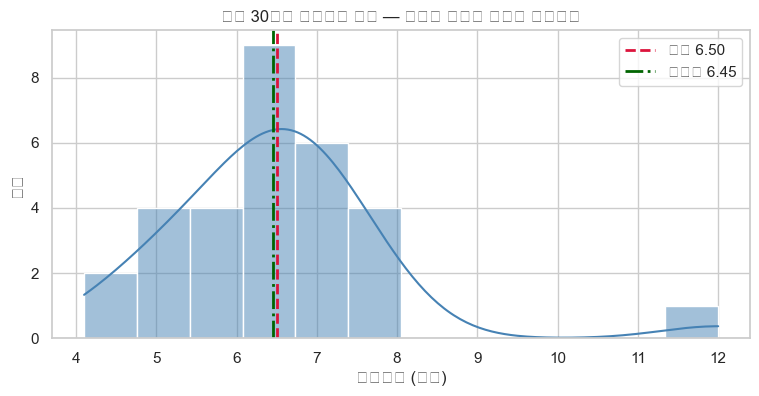

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(sleep, x="sleep_hours", bins=12, kde=True, ax=ax, color="steelblue")
ax.axvline(lib_mean, color="crimson", linestyle="--", linewidth=2, label=f"평균 {lib_mean:.2f}")
ax.axvline(lib_median, color="darkgreen", linestyle="-.", linewidth=2, label=f"중앙값 {lib_median:.2f}")
ax.set_title("환자 30명의 수면시간 분포 — 평균이 오른쪽 꼬리에 끌려간다")
ax.set_xlabel("수면시간 (시간)"); ax.set_ylabel("빈도")
ax.legend()
plt.show()


한 환자가 12 시간을 잔 영향으로 평균선(빨강) 이 중앙값선(초록) 보다 살짝 *오른쪽* 에 있습니다. 환자 대부분의 *전형적인 수면시간* 을 표현하는 데에는 중앙값이 더 정직합니다.


## 2. 같은 평균, 세 가지 모양

*평균이 같은데 분포가 전혀 다른* 세 데이터를 한 화면에서 비교합니다. 이게 평균만 보고 결정하면 안 되는 이유입니다.


In [6]:
n = 1000
target_mean = 6.5

# (A) 대칭 정규분포
a = rng.normal(loc=target_mean, scale=1.0, size=n)

# (B) 우측 꼬리 (지수 분포 + 평행 이동)
b_raw = rng.exponential(scale=1.0, size=n)
b = b_raw - b_raw.mean() + target_mean

# (C) 양봉 분포 (두 정규의 혼합)
k = rng.binomial(1, 0.5, size=n)
c_low = rng.normal(loc=4.5, scale=0.6, size=n)
c_high = rng.normal(loc=8.5, scale=0.6, size=n)
c = np.where(k == 1, c_high, c_low)
c = c - c.mean() + target_mean  # 평균을 6.5 로 정렬

for name, arr in zip(["A 대칭", "B 우측꼬리", "C 양봉"], [a, b, c]):
    print(f"{name}: mean={arr.mean():.3f}, median={np.median(arr):.3f}")


A 대칭: mean=6.471, median=6.506
B 우측꼬리: mean=6.500, median=6.203
C 양봉: mean=6.500, median=6.247


/var/folders/2k/bw6cqqg15kz3t34cn88481lc0000gn/T/ipykernel_41954/3335412121.py:8: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/2k/bw6cqqg15kz3t34cn88481lc0000gn/T/ipykernel_41954/3335412121.py:8: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/2k/bw6cqqg15kz3t34cn88481lc0000gn/T/ipykernel_41954/3335412121.py:8: UserWarning: Glyph 52845 (\N{HANGUL SYLLABLE CING}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/2k/bw6cqqg15kz3t34cn88481lc0000gn/T/ipykernel_41954/3335412121.py:8: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/2k/bw6cqqg15kz3t34cn88481lc0000gn/T/ipykernel_41954/3335412121.py:8: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()
/var/folders/2k/bw6cqqg1

/Users/yngn/ws/statistics-for-data-science/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/yngn/ws/statistics-for-data-science/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 45824 (\N{HANGUL SYLLABLE DAE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/yngn/ws/statistics-for-data-science/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52845 (\N{HANGUL SYLLABLE CING}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/yngn/ws/statistics-for-data-science/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/yngn/ws/statistics-for-data-science/.venv/lib/python3.12/site-pa

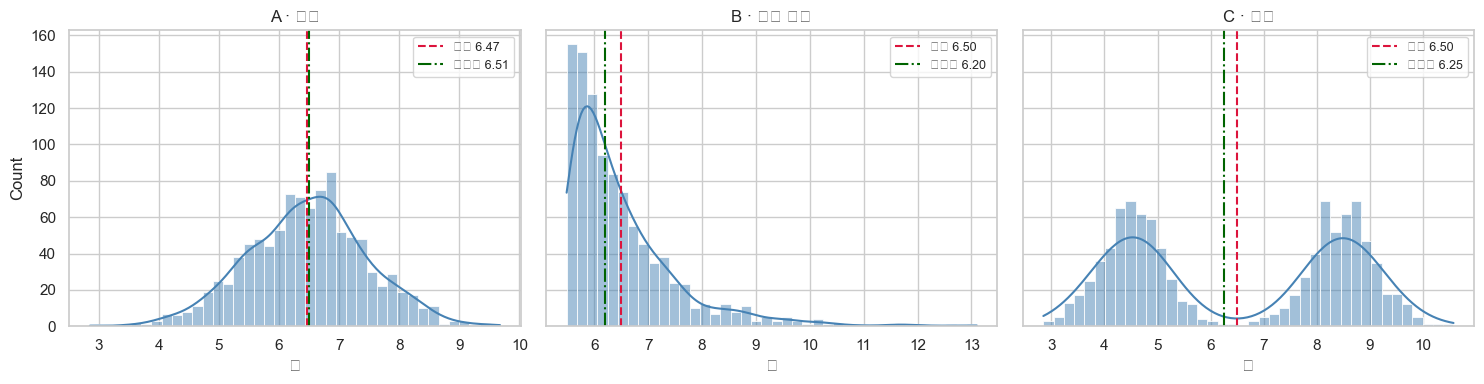

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, name, arr in zip(axes, ["A · 대칭", "B · 우측 꼬리", "C · 양봉"], [a, b, c]):
    sns.histplot(arr, bins=40, ax=ax, kde=True, color="steelblue")
    ax.axvline(arr.mean(), color="crimson", linestyle="--", label=f"평균 {arr.mean():.2f}")
    ax.axvline(np.median(arr), color="darkgreen", linestyle="-.", label=f"중앙값 {np.median(arr):.2f}")
    ax.set_title(name)
    ax.set_xlabel("값"); ax.legend(loc="upper right", fontsize=9)
plt.tight_layout(); plt.show()


세 분포 모두 평균은 6.5 에 가깝지만,

- **A 대칭** 에서는 평균이 분포의 *진짜 중심* 입니다. 평균만 보고해도 큰 손해 없음.
- **B 우측 꼬리** 에서는 평균이 중앙값보다 *오른쪽* 에 있습니다. *전형적인* 값을 묻는 질문에는 중앙값이 더 정직.
- **C 양봉** 에서는 평균선(6.5) 부근에 데이터가 *거의 없습니다*. 평균 한 점은 사실상 아무도 대표하지 않습니다.


## 3. 시나리오 ② — 양봉 평점이 평균에 가려질 때

평점 1~5 점을 *호평·혹평이 거의 반반* 인 분포로 만들어 보고, 평균만 봤을 때 어떻게 호도되는지 봅니다.


In [8]:
ratings = rng.choice([1, 2, 4, 5], size=400, p=[0.20, 0.30, 0.25, 0.25])
print(f"평균: {ratings.mean():.2f}, 중앙값: {np.median(ratings):.2f}")
vals, counts = np.unique(ratings, return_counts=True)
for v, c_ in zip(vals, counts):
    print(f"  {v}점: {c_}회 ({c_/len(ratings):.0%})")


평균: 2.89, 중앙값: 2.00
  1점: 96회 (24%)
  2점: 123회 (31%)
  4점: 91회 (23%)
  5점: 90회 (22%)


/Users/yngn/ws/statistics-for-data-science/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/yngn/ws/statistics-for-data-science/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/yngn/ws/statistics-for-data-science/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/yngn/ws/statistics-for-data-science/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/yngn/ws/statistics-for-data-science/.venv/lib/python3.12/site-pack

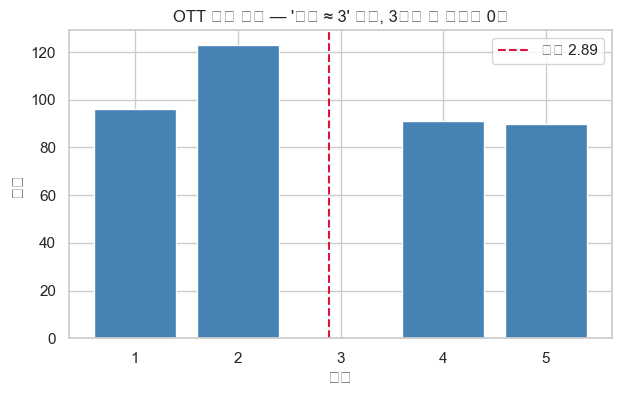

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(vals, counts, color="steelblue", edgecolor="white")
ax.axvline(ratings.mean(), color="crimson", linestyle="--", label=f"평균 {ratings.mean():.2f}")
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_title("OTT 신작 평점 — '평균 ≈ 3' 인데, 3점을 준 사람은 0명")
ax.set_xlabel("별점"); ax.set_ylabel("인원")
ax.legend()
plt.show()


*"평균 평점 3.x"* 라는 한 줄은 이 영화가 *보통* 이라는 인상을 줍니다. 그런데 실제 분포에는 3 점을 준 사람이 한 명도 없습니다 — 호불호가 갈리는 콘텐츠입니다. 추천·마케팅 의사결정에는 *분포의 다봉성* 이 평균보다 훨씬 풍부한 정보를 제공합니다.


## 4. 함정 시뮬레이션 — 한 사람이 평균을 얼마나 흔드는가

30 명 중 한 명만 *극단적으로 잠을 많이 잤다* 고 가정하고 그 사람의 시간을 0~24 까지 바꿔 봅니다. 평균과 중앙값이 어떻게 반응하는지 한 그림에 그립니다.


/Users/yngn/ws/statistics-for-data-science/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 54620 (\N{HANGUL SYLLABLE HAN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/yngn/ws/statistics-for-data-science/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51032 (\N{HANGUL SYLLABLE YI}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/yngn/ws/statistics-for-data-science/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/yngn/ws/statistics-for-data-science/.venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 47732 (\N{HANGUL SYLLABLE MYEON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/yngn/ws/statistics-for-data-science/.venv/lib/python3.12/site-package

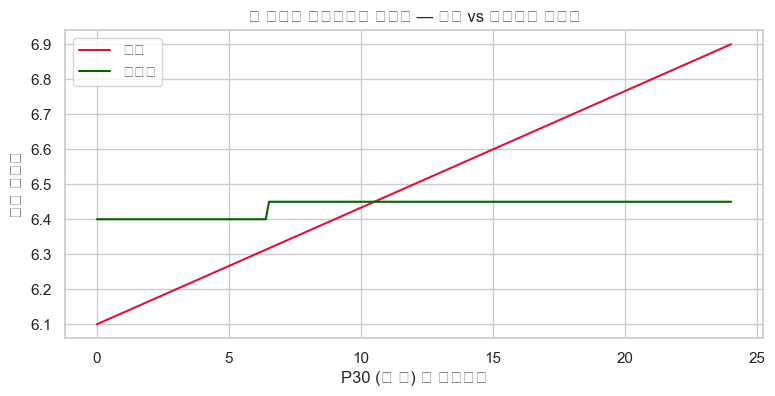

In [10]:
base = sleep["sleep_hours"].iloc[:-1].to_numpy()  # P30 제외한 29명
outlier_values = np.linspace(0, 24, 200)
means = np.array([np.mean(np.append(base, v)) for v in outlier_values])
medians = np.array([np.median(np.append(base, v)) for v in outlier_values])

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(outlier_values, means, color="crimson", label="평균")
ax.plot(outlier_values, medians, color="darkgreen", label="중앙값")
ax.set_title("한 환자의 수면시간을 바꾸면 — 평균 vs 중앙값의 흔들림")
ax.set_xlabel("P30 (한 명) 의 수면시간"); ax.set_ylabel("요약 통계량")
ax.legend()
plt.show()


평균(빨강) 은 한 사람의 값이 0 에서 24 로 변하는 동안 *약 1 시간* 가까이 흔들립니다. 중앙값(초록) 은 거의 변하지 않습니다. 한 명의 *극단값에 강건한 도구* 가 필요하면 중앙값을 떠올리세요.


## 5. 정리 — 같은 데이터, 세 가지 시선

같은 30 명의 수면 데이터를 다시 한 번 *세 도구* 로 묘사해 봅시다.


In [11]:
summary = pd.Series({
    "평균": sleep["sleep_hours"].mean(),
    "중앙값": sleep["sleep_hours"].median(),
    "최빈값": stats.mode(sleep["sleep_hours"].to_numpy(), keepdims=False).mode,
    "최솟값": sleep["sleep_hours"].min(),
    "최댓값": sleep["sleep_hours"].max(),
}).round(3)
summary


평균      6.50
중앙값     6.45
최빈값     6.40
최솟값     4.10
최댓값    12.00
dtype: float64

이 요약표 한 장은 *평균만 적힌 한 줄 보고서* 보다 훨씬 많은 결정을 가능하게 합니다. 다음 챕터에서는 이 요약에 *퍼짐* 을 한 줄 더 얹습니다.


## 6. 직접 답해 보기 — 회고로 넘어가기 전에

1. 한 줄로 정리하면, *평균이 거짓말하는 순간* 이란 어떤 순간인가?
2. 친구에게 "평균이 같다고 같은 분포는 아니다" 를 설명한다면 어떤 그림을 그리겠는가?
3. 평균이 *충분히 정직한* 상황을 한 가지 떠올려 보자. 어떤 조건이 갖춰졌을 때인가?

답이 모이면 [`reflection.md`](reflection.md) 로 옮겨 적어 두세요.
